# Task 1a

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Load data
df = pd.read_csv("dataset_mood_smartphone.csv") 

In [2]:
# Show first few rows
df.head(5)

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.0
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.0
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.0
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.0
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.0


In [5]:
# Make time datetime
df['time'] = pd.to_datetime(df['time'])

## Basic properties

In [6]:
print(f"Total records: {len(df)}")
print(f"Unique users: {df['id'].nunique()}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}. Total days: {(df['time'].max() - df['time'].min()).days}")
print(f"Unique variables: {df['variable'].nunique()}")
print(f"Variable names: {np.array(df['variable'].unique())}")

# See how many records there are per user
records_per_user = df.groupby('id').size().sort_values()
print(f"Mean records per user: {records_per_user.mean():.0f}. Min: {records_per_user.min()}, Max: {records_per_user.max()}")

Total records: 376912
Unique users: 27
Date range: 2014-02-17 07:00:52.197000 to 2014-06-09 00:00:00. Total days: 111
Unique variables: 19
Variable names: ['mood' 'circumplex.arousal' 'circumplex.valence' 'activity' 'screen'
 'call' 'sms' 'appCat.builtin' 'appCat.communication'
 'appCat.entertainment' 'appCat.finance' 'appCat.game' 'appCat.office'
 'appCat.other' 'appCat.social' 'appCat.travel' 'appCat.unknown'
 'appCat.utilities' 'appCat.weather']
Mean records per user: 13960. Min: 2848, Max: 21999


## Data Distributions (Scatterplots)

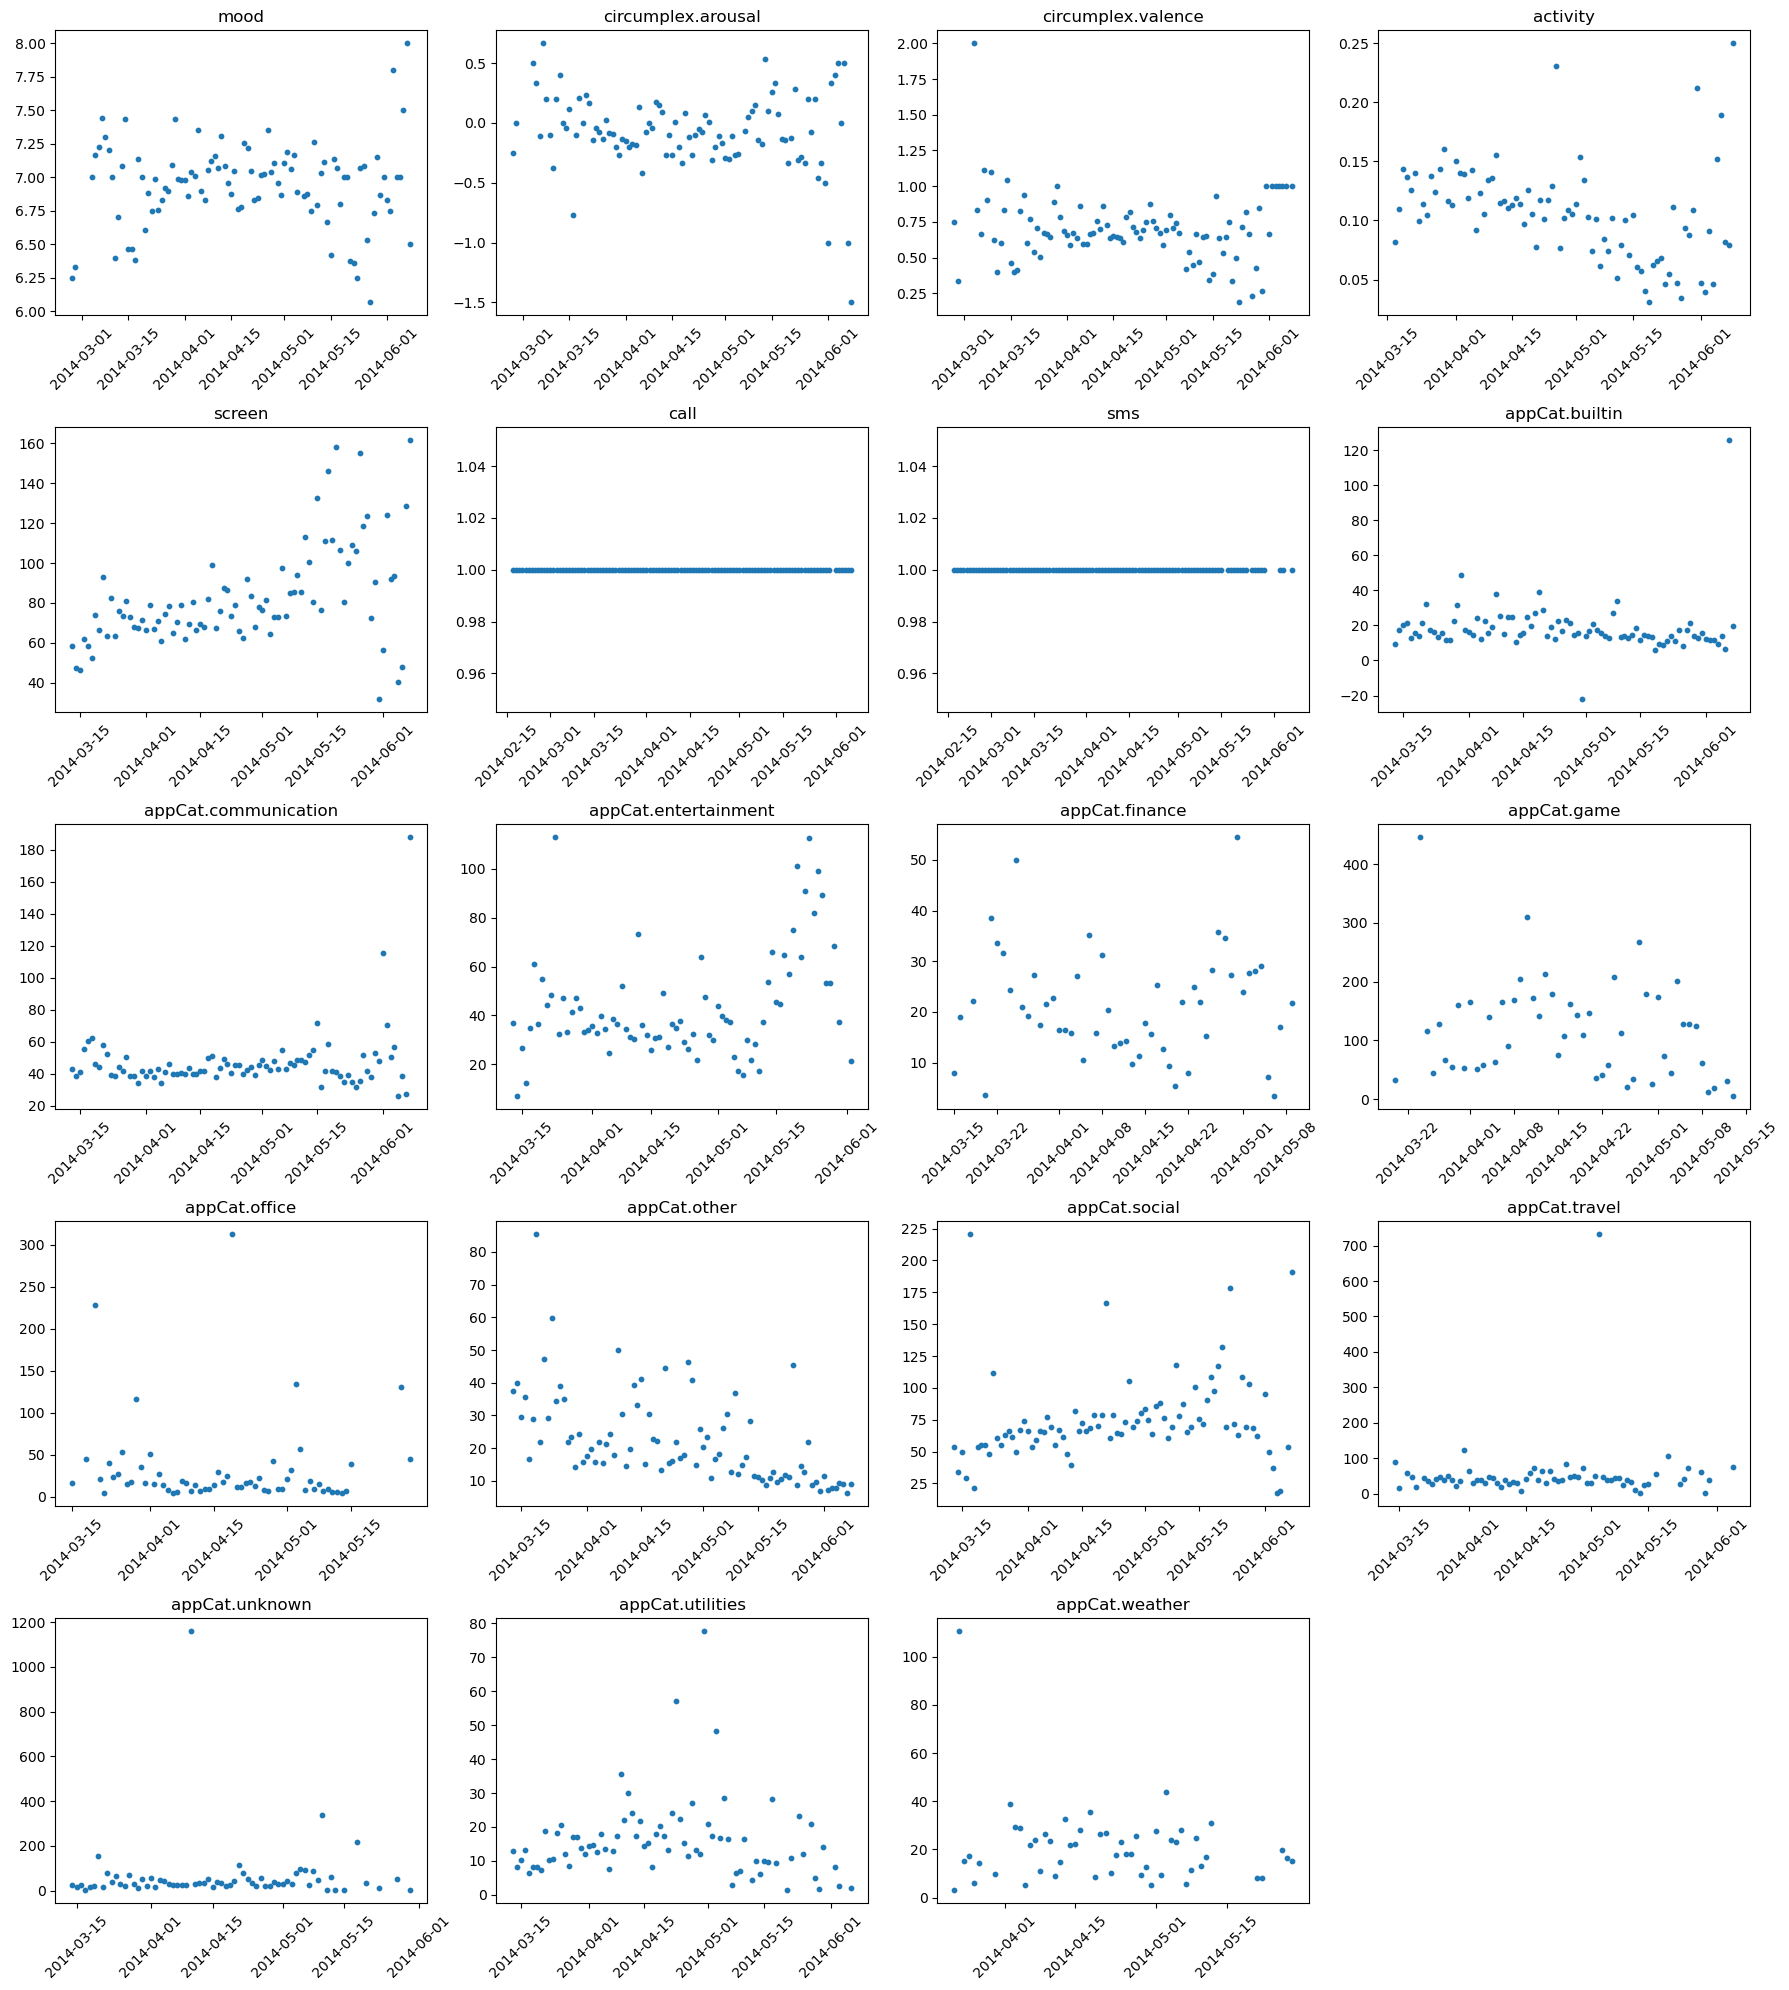

In [7]:
# Can be used to visualize aggregated data 

variables = np.array(df["variable"].unique())
n = len(variables)

# Plot 

cols = 4 
rows = math.ceil(n/cols)

fig, axes = plt.subplots(rows, cols, figsize = (18, 4*rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    raw = df[df["variable"] == var].copy()

    daily = raw.groupby(pd.Grouper(key="time", freq="D"))["value"].mean()

    axes[i].scatter(daily.index, daily.values, s=10)
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Value ranges per variable sorted by count
df.groupby('variable')['value'].describe().round(3).sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
screen,96578.0,75.335,253.822,0.035,5.322,20.044,62.540,9867.007
appCat.builtin,91288.0,18.538,415.989,-82798.871,2.020,4.038,9.922,33960.246
appCat.communication,74276.0,43.344,128.913,0.006,5.218,16.226,45.476,9830.777
appCat.entertainment,27125.0,37.576,262.960,-0.011,1.334,3.391,14.922,32148.677
activity,22965.0,0.116,0.187,0.000,0.000,0.022,0.158,1.000
appCat.social,19145.0,72.402,261.552,0.094,9.030,28.466,75.372,30000.906
appCat.other,7650.0,25.811,112.781,0.014,7.019,10.028,16.829,3892.038
appCat.office,5642.0,22.579,449.601,0.003,2.004,3.106,8.044,32708.818
mood,5641.0,6.993,1.033,1.000,7.000,7.000,8.000,10.000


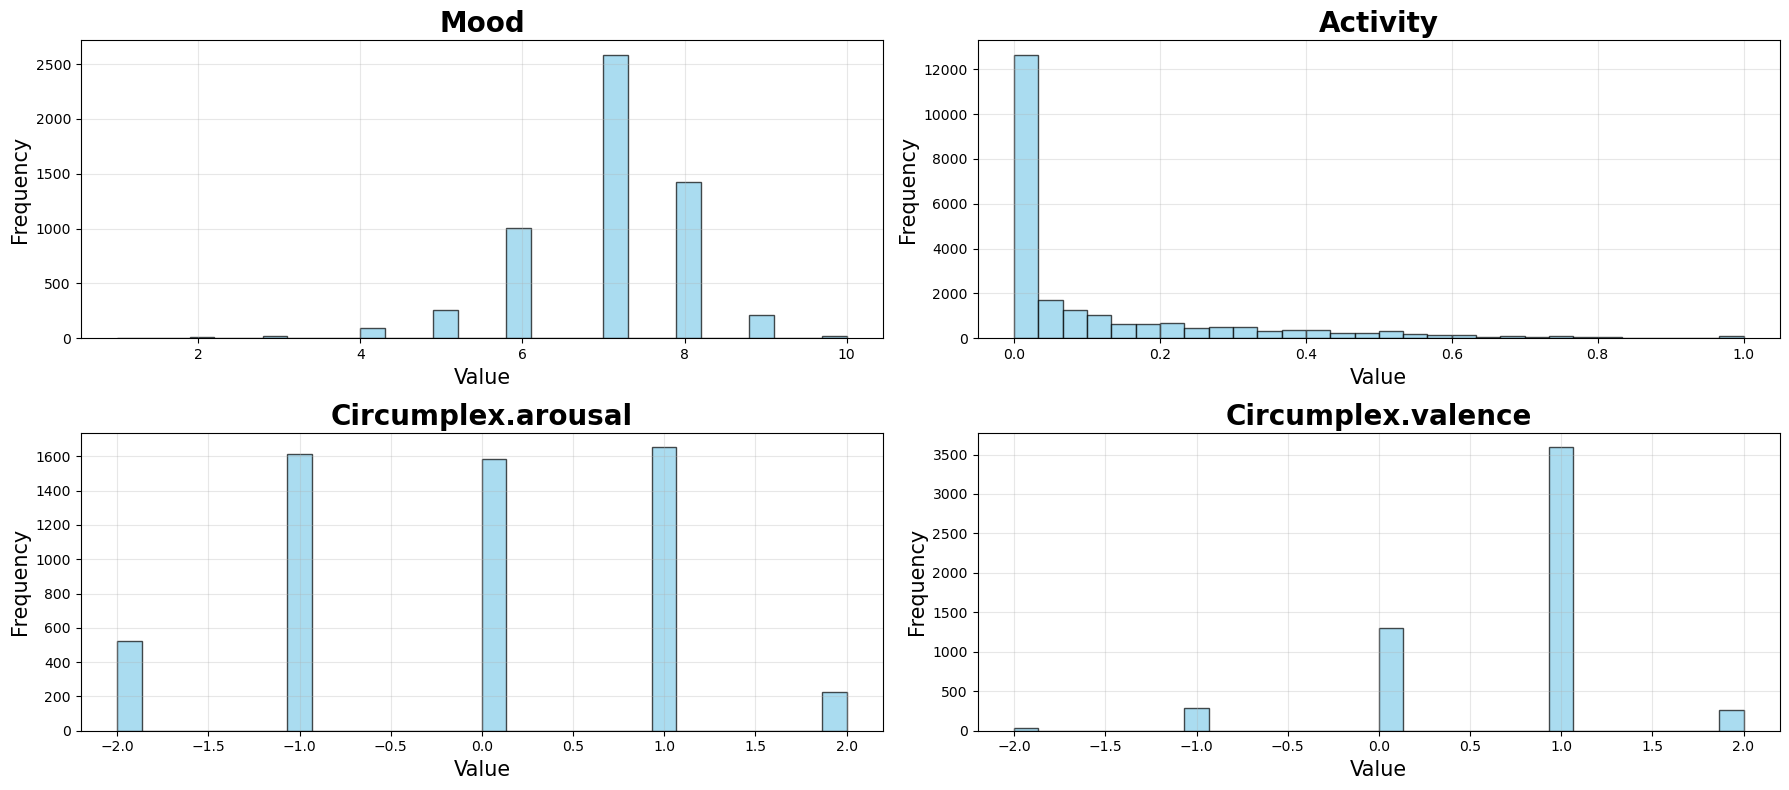

In [23]:
variables = ["mood", "activity", "circumplex.arousal", "circumplex.valence"]
cols = 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    data = df[df["variable"] == var]["value"].dropna()
    
    axes[i].hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'{var.capitalize()}', fontsize=20, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=15)
    axes[i].set_ylabel('Frequency', fontsize=15)
    axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

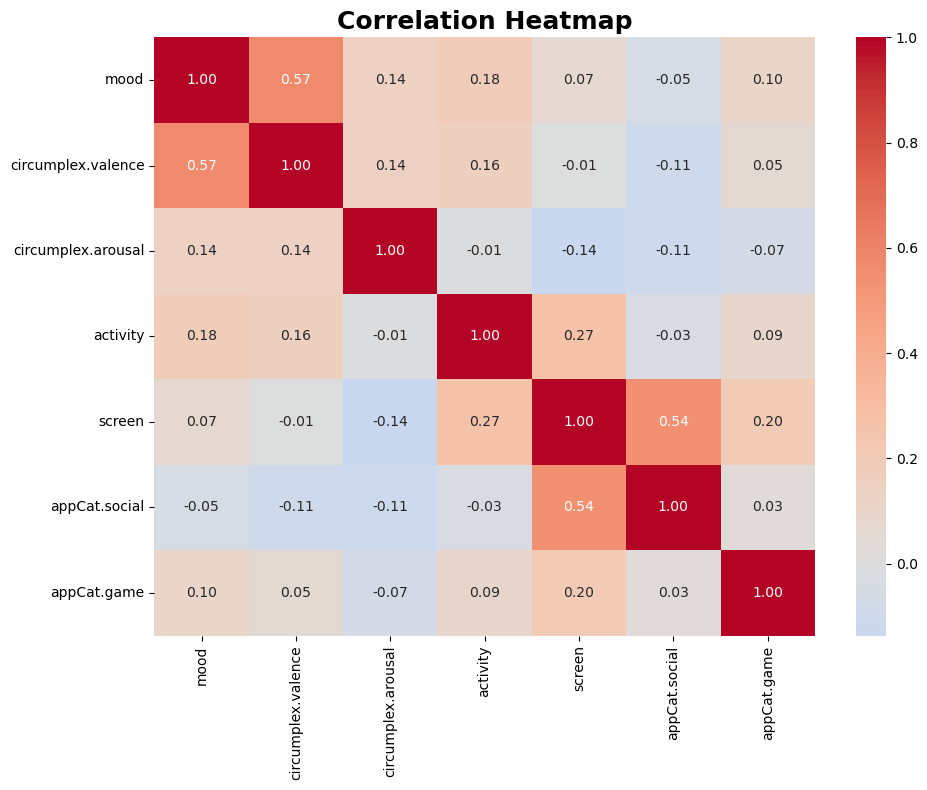

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# has to be the dataset before filling in
pivoted = pd.read_csv("data_cleaned.csv")

# Select specific variables for correlation
selected_vars = ['mood', 'circumplex.valence', 'circumplex.arousal', 'activity', 'screen', 'appCat.social', 'appCat.game']
numeric_df = pivoted[selected_vars]

corr = numeric_df.corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")

plt.title("Correlation Heatmap", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

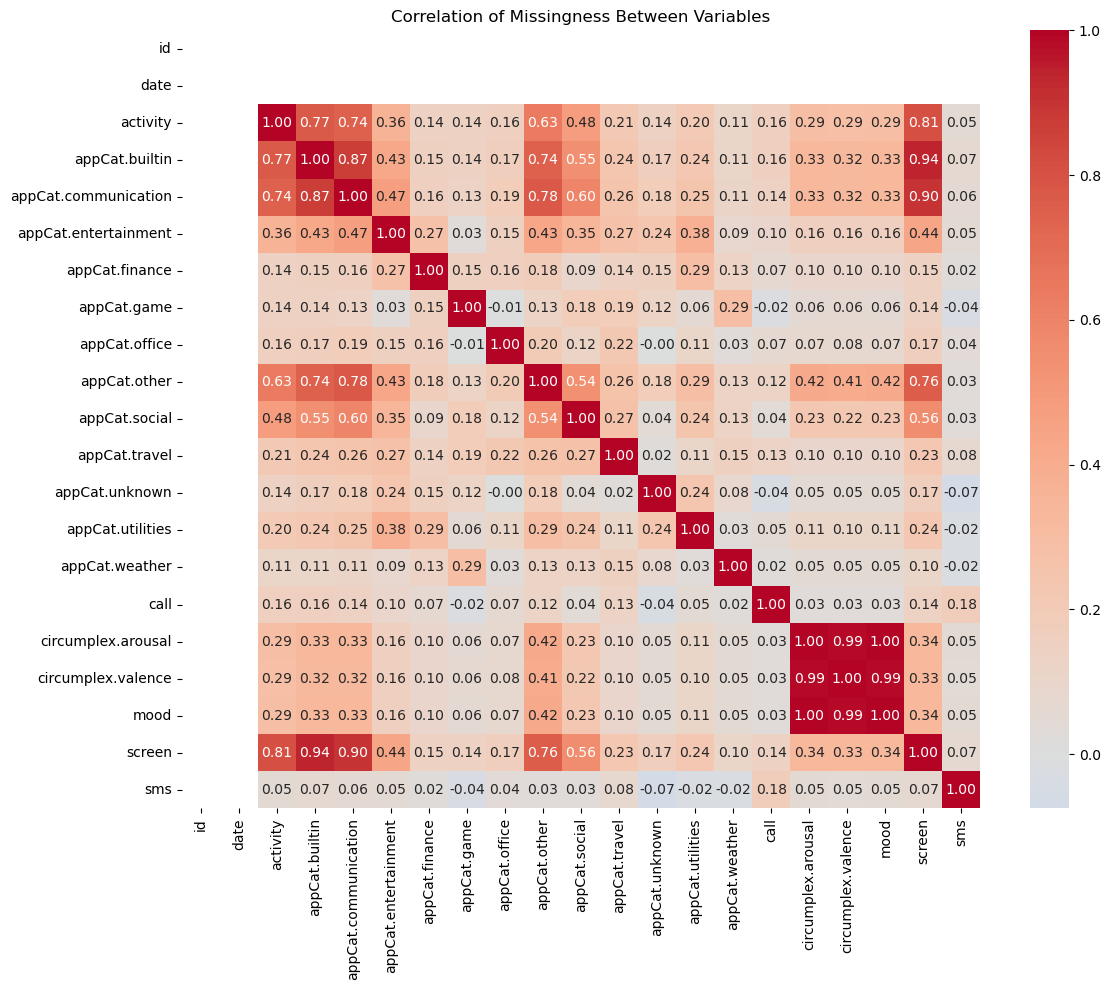

In [34]:
# Create missingness indicator (1 = missing, 0 = present)
df_c = pd.read_csv("data_cleaned.csv")
missing_df = df_c.isnull().astype(int)

# Correlation of missingness
missing_corr = missing_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(missing_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")

plt.title("Correlation of Missingness Between Variables")
plt.tight_layout()
plt.show()

## Some plots to understand the data

### Plots showing when users start logging data

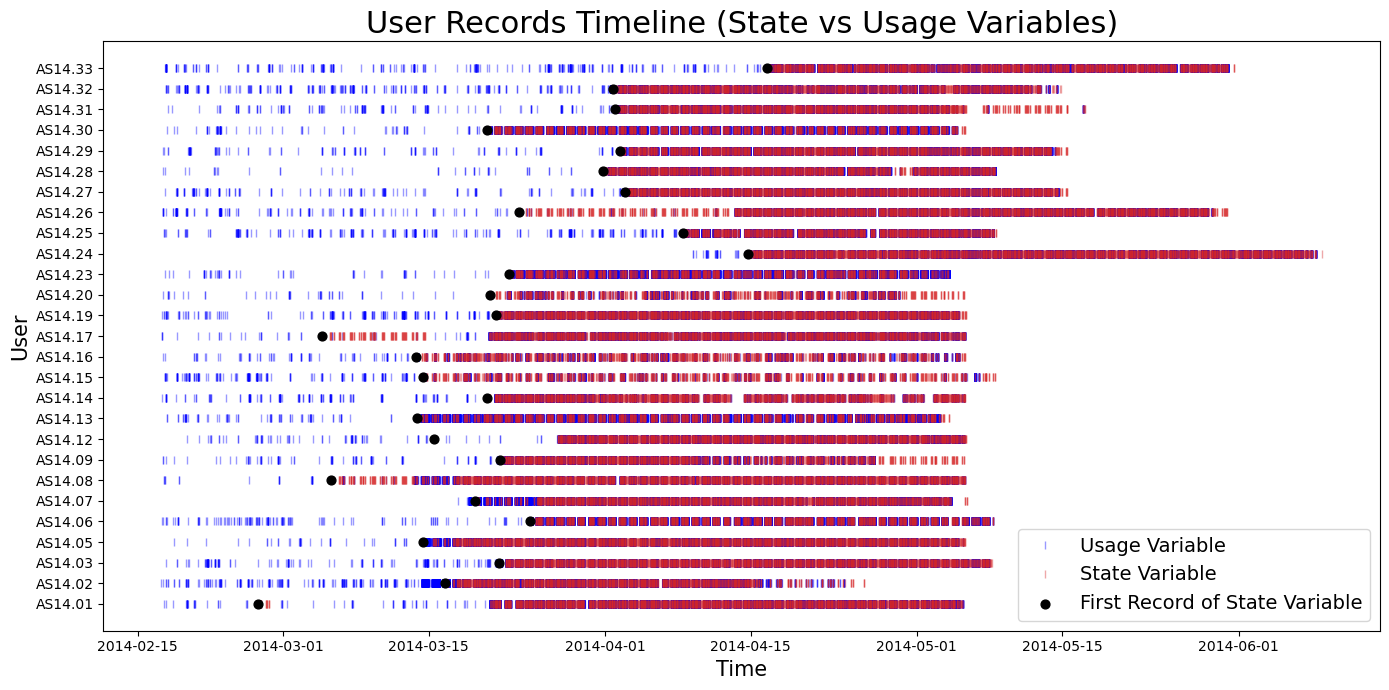

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

STATE_VARS = ["mood","activity","circumplex.arousal","circumplex.valence"]

df["time"] = pd.to_datetime(df["time"])

# first state timestamp per user
first_state = (
    df[df["variable"].isin(STATE_VARS)]
    .dropna(subset=["value"])
    .groupby("id")["time"]
    .min()
)

plt.figure(figsize=(14,7))

ids = sorted(df["id"].unique())
y = {uid:i for i,uid in enumerate(ids)}

for uid, g in df.groupby("id"):
    g = g.sort_values("time")

    # non-state ticks
    g_non = g[~g["variable"].isin(STATE_VARS)]
    plt.plot(
        g_non["time"],
        [y[uid]]*len(g_non),
        "|",
        color="blue",
        alpha=0.4,
        markersize=6
    )

    # state ticks
    g_state = g[g["variable"].isin(STATE_VARS)]
    plt.plot(
        g_state["time"],
        [y[uid]]*len(g_state),
        "|",
        color="tab:red",
        alpha=0.4,
        markersize=6
    )

    # first state marker (optional, keep/remove as you like)
    if uid in first_state:
        plt.scatter(first_state[uid], y[uid],
                    color="black", s=40, zorder=3)

plt.yticks(list(y.values()), list(y.keys()))
plt.title("User Records Timeline (State vs Usage Variables)", fontsize=22)
plt.xlabel("Time", fontsize=15)
plt.ylabel("User", fontsize=15)
plt.legend(["Usage Variable", "State Variable", "First Record of State Variable"], loc="lower right", fontsize=14)

plt.tight_layout()
plt.show()

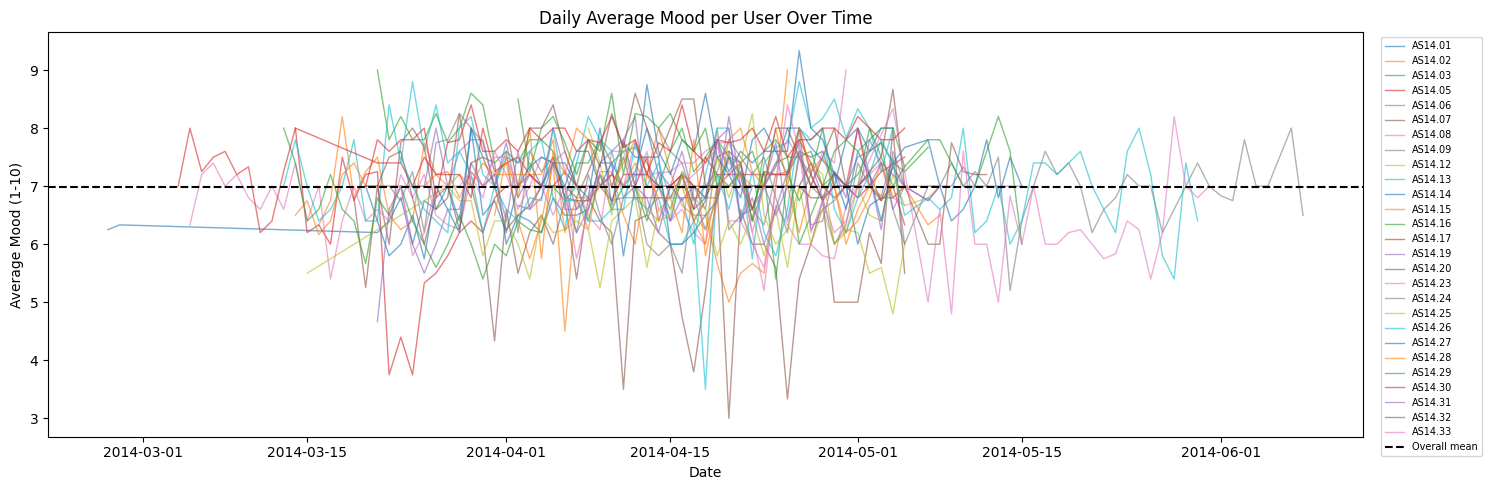

In [ ]:
# Mood over time per user
mood_df = df[df['variable'] == 'mood'].copy()
mood_df['date'] = mood_df['time'].dt.date

# Daily average mood per user
daily_mood = mood_df.groupby(['id', 'date'])['value'].mean().reset_index()

# Plot one line per user
fig, ax = plt.subplots(figsize=(15, 5))
for user_id, group in daily_mood.groupby('id'):
    ax.plot(group['date'], group['value'], alpha=0.6, linewidth=1, label=str(user_id))

ax.set_title('Daily Average Mood per User Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Average Mood (1-10)')
ax.axhline(daily_mood['value'].mean(), color='black', linestyle='--', linewidth=1.5, label='Overall mean')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()